In [23]:
import pandas as pd

campaign = pd.read_csv('https://raw.githubusercontent.com/byui-cse/cse450-course/master/data/bank.csv')

campaign.head()
# display(campaign.columns)

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


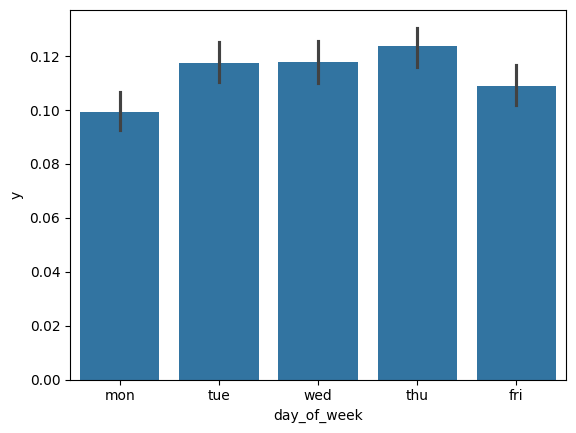

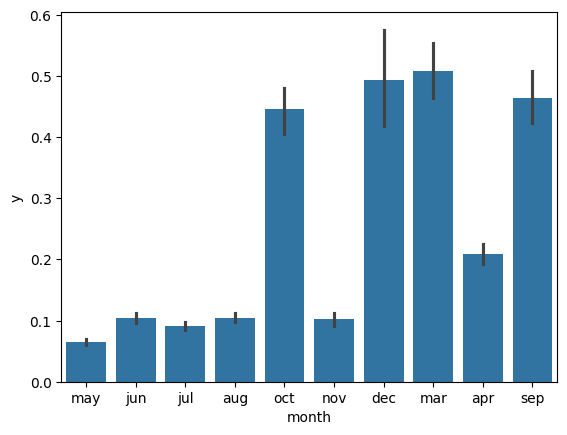

,age,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,37069.000000,37069.000000,37069.000000,37069.000000,37069.000000,37069.000000,37069.000000,37069.000000,37069.000000
mean,40.025493,2.564407,962.221803,0.173730,0.081526,93.576551,-40.494829,3.621945,5167.010650
std,10.435288,2.764084,187.531477,0.496159,1.572287,0.579339,4.628895,1.734496,72.294476
min,17.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.634000,4963.600000
25%,32.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.344000,5099.100000
50%,38.000000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000
75%,47.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000
max,98.000000,56.000000,999.000000,7.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000


<StringArray>
['may', 'jun', 'jul', 'aug', 'oct', 'nov', 'dec', 'mar', 'apr', 'sep']
Length: 10, dtype: str

In [24]:
import seaborn as sns
import matplotlib.pyplot as plt

# Timing
# Euribor 3m is the interest rate that was given

campaign.replace({'no': 0, 'yes': 1}, inplace=True)
sns.barplot(data=campaign, x='day_of_week', y='y')
plt.show()
sns.barplot(data=campaign, x='month', y='y')
plt.show()
# sns.lineplot(data=campa


display(campaign.describe())
display(campaign.month.unique())

In [25]:
# confidence rel to eurobor


# Compute some custom cols:
campaign['conf_to_eub'] = campaign['cons.conf.idx'] * campaign['euribor3m']
campaign['conf_to_eub_by_emp'] = campaign['cons.conf.idx'] * campaign['euribor3m'] * campaign['nr.employed']

# campaign['eco_job'] = campaign['conf_to_eub'] * 
# campaign['conf_to_eub'] = campaign['cons.conf.idx'] * campaign['euribor3m']


# Pick which columns I want:

keep_cols = ['age', 'job', 'marital', 'education', 'housing', 'loan',
       'contact', 'month', 'day_of_week', 'campaign', 'pdays', 'previous',
       'poutcome', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx',
       'euribor3m', 'nr.employed', 'conf_to_eub', 'conf_to_eub_by_emp', 'y']

campaign = campaign[campaign.columns.intersection(keep_cols)]

campaign_filtered = pd.get_dummies(campaign, columns=['job', 'marital', 'contact', 'day_of_week', 'poutcome'])

# display(campaign_filtered.head())

# Clean up data and encode to numbers
education_map = {
    "illiterate" : 1,
    "unknown" : 2,
    "basic.4y" : 3,
    "basic.6y" : 4,
    "basic.9y" : 5,
    "high.school" : 6,
    "professional.course" : 7,
    "university.degree" : 8
}
campaign_filtered['education'] = campaign['education'].map(education_map)

month_map = {
    'may' : 10, 
    'jun' : 6, 
    'jul' : 9, 
    'aug' : 8, 
    'oct' : 4, 
    'nov' : 7, 
    'dec' : 2, 
    'mar' : 1, 
    'apr' : 5, 
    'sep' : 3,
    'jan' : 11,
    'feb' : 12
}
campaign_filtered['month'] = campaign['month'].map(month_map)
# display(campaign_filtered.head())


campaign_filtered['y'] = campaign_filtered['y'].replace({'no': 0, 'yes': 1, 'unknown': -1})
campaign_filtered['housing'] = campaign_filtered['housing'].replace({'no': 1, 'yes': 2, 'unknown': 0})
campaign_filtered['loan'] = campaign_filtered['loan'].replace({'no': 1, 'yes': 2, 'unknown': 0})

# display(campaign_filtered.head())


#campaign.drop(columns = ['contact', 'month', 'day_of_week'])
features = list(campaign_filtered.columns)
features.remove('y')
# display(features)
# display(campaign_filtered[campaign_filtered.isna().any(axis=1)])
# display(campaign_filtered[campaign_filtered.isin(['unknown']).any(axis=1)])

In [26]:
display(campaign_filtered[campaign_filtered.isna().any(axis=1)])
#display(campaign_filtered[(campaign_filtered == 'unknown').any(axis=1)])

#print(len(features))

#print('y')
#display(campaign_filtered['y'].unique())

#for feature in features:
#    print(feature)
#    display(campaign_filtered[feature].unique())

,age,education,housing,loan,month,campaign,pdays,previous,emp.var.rate,cons.price.idx,...,contact_cellular,contact_telephone,day_of_week_fri,day_of_week_mon,day_of_week_thu,day_of_week_tue,day_of_week_wed,poutcome_failure,poutcome_nonexistent,poutcome_success


In [27]:
# Our target variable:
import numpy as np
Y = np.array(campaign_filtered['y'].astype('int64')).flatten()

from sklearn.utils.multiclass import type_of_target
print(type_of_target(Y))
# print(Y.isnull().sum())


# Our input variables:
X = campaign_filtered[features]


import sklearn as skl

dir(skl)

X_train, X_test, Y_train, Y_test = skl.model_selection.train_test_split(X, Y, test_size=0.2)

binary


In [28]:
# # TRAIN A NEAREST NEIGHBORS MODEL

# # Train the model:
# from sklearn.neighbors import KNeighborsClassifier
# from sklearn.metrics import classification_report
# clf = KNeighborsClassifier(n_neighbors=31, n_jobs=6)
# clf.fit(X_train, Y_train)

# # Make predictions
# predictions = clf.predict(X_test)

# # Just a quick comparison with y_test to see if they match up
# matches = predictions == Y_test
# failed = 0
# passed = 0
# for match in matches:
#     if match == False:
#         failed += 1
#     else:
#         passed += 1

# print(f"Failed: {failed}")
# print(f"Passed: {passed}")

# print(classification_report(Y_test, predictions))

In [29]:
# # %pip install xgboost

# from xgboost import XGBClassifier
# from sklearn.metrics import classification_report

# # Calculate the ratio for your imbalanced data
# # Example: 1000 zeros and 100 ones = ratio of 10
# ratio = float(sum(Y_train == 0)) / sum(Y_train == 1)
# display(ratio)

# clf_xgb = XGBClassifier(
#     n_estimators=50,
#     max_depth=10,
#     learning_rate=0.1,
#     scale_pos_weight=ratio,
#     # use_label_encoder=False,
#     eval_metric='logloss',
#     min_child_weight=1,
#     n_jobs=6
# )

# clf_xgb.fit(X_train, Y_train)

# # Test the model
# y_pred = clf_xgb.predict(X_test)

# # Check the results - look specifically at "Recall" for class 1
# print(classification_report(Y_test, y_pred))


# import matplotlib.pyplot as plt

# # Get importance scores
# importances = clf_xgb.feature_importances_
# indices = np.argsort(importances)[::-1]

# # Print the ranking
# print("Feature ranking:")
# for f in range(X.shape[1]):
#     print(f"{f + 1}. feature {features[indices[f]]} ({importances[indices[f]]})")

# # Plot it
# plt.figure(figsize=(10, 6))
# plt.title("Feature Importances")
# plt.bar(range(X.shape[1]), importances[indices], align="center")
# plt.xticks(range(X.shape[1]), [features[i] for i in indices], rotation=90)
# plt.show()

Running with a max_depth: 14
Failed: 973
Passed: 6441
              precision    recall  f1-score   support

           0       0.94      0.91      0.92      6563
           1       0.44      0.54      0.49       851

    accuracy                           0.87      7414
   macro avg       0.69      0.73      0.71      7414
weighted avg       0.88      0.87      0.87      7414

Feature ranking:
1. feature conf_to_eub (0.12529198287104482)
2. feature conf_to_eub_by_emp (0.12098310631001172)
3. feature euribor3m (0.087536808203724)
4. feature age (0.07171910246012417)
5. feature nr.employed (0.06714235111076827)
6. feature emp.var.rate (0.06674808370259992)
7. feature month (0.043450699486893306)
8. feature campaign (0.042805989973283956)
9. feature cons.conf.idx (0.037743964478693395)
10. feature education (0.035834800162217344)
11. feature cons.price.idx (0.030476324019528198)
12. feature pdays (0.023972245987442187)
13. feature poutcome_success (0.020677975791663597)
14. feature housi

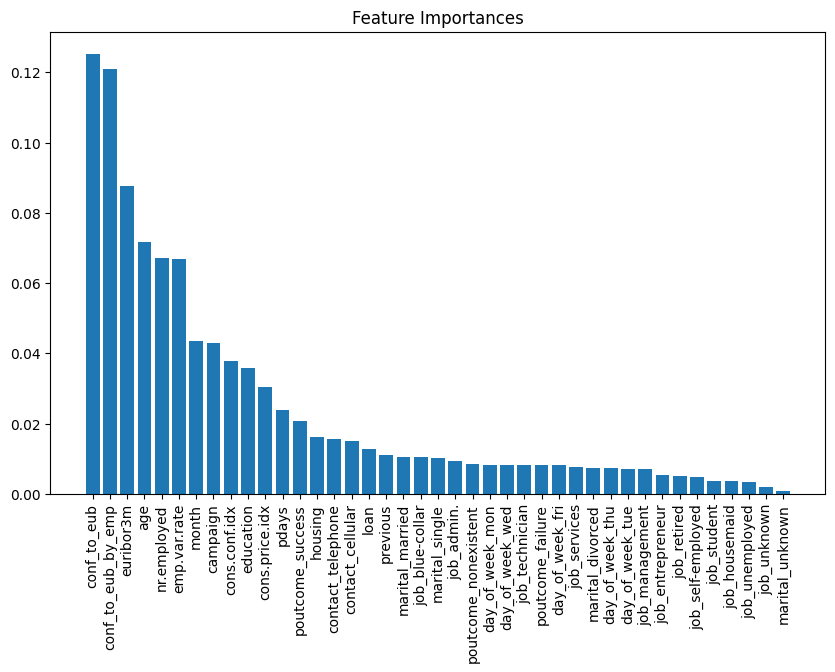

In [44]:
# TRAIN A RANDOM FOREST MODEL

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

depth = 14
print(f"Running with a max_depth: {depth}")
clf = RandomForestClassifier(n_estimators=97,
                            max_depth=depth,
                            # min_samples_split=2,
                            max_features="log2",
                            class_weight='balanced',
                            n_jobs=6,
                            random_state = 8642,)
clf.fit(X_train, Y_train)


# Make predictions
predictions = clf.predict(X_test)

# Just a quick comparison with y_test to see if they match up
matches = predictions == Y_test
failed = 0
passed = 0
for match in matches:
    if match == False:
        failed += 1
    else:
        passed += 1

print(f"Failed: {failed}")
print(f"Passed: {passed}")
print(classification_report(Y_test, predictions))

import matplotlib.pyplot as plt

# Get importance scores
importances = clf.feature_importances_
indices = np.argsort(importances)[::-1]

# Print the ranking
print("Feature ranking:")
for f in range(X.shape[1]):
    print(f"{f + 1}. feature {features[indices[f]]} ({importances[indices[f]]})")

# Plot it
plt.figure(figsize=(10, 6))
plt.title("Feature Importances")
plt.bar(range(X.shape[1]), importances[indices], align="center")
plt.xticks(range(X.shape[1]), [features[i] for i in indices], rotation=90)
plt.show()

from pickle import dump
with open("lastmodel.pkl", "wb") as f:
    dump(clf, f, protocol=5)

In [43]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

# Tracking variables for the overall winner
best_score = -1
best_params = {}

# Define your ranges
depth_range = range(2, 50)
# range(start, stop, step) -> 250 + 1 to include 250 in the test
estimator_range = range(25, 251, 24) 

for n_trees in estimator_range:
    for depth in depth_range:
        print(f"Testing: n_estimators={n_trees}, max_depth={depth}...", end="\r")
        
        clf = RandomForestClassifier(
            n_estimators=n_trees,
            max_depth=depth,
            max_features="log2",
            class_weight='balanced',
            n_jobs=6,
            random_state=8642 # Added for consistent results during testing
        )
        
        clf.fit(X_train, Y_train)
        predictions = clf.predict(X_test)
        
        # Calculate metrics
        failed = (predictions != Y_test).sum()
        report = classification_report(Y_test, predictions, output_dict=True)
        
        # Pull precision/recall for class '1' (ensure '1' matches your Y_train labels)
        p1 = report['1']['precision']
        r1 = report['1']['recall']
        
        # Scoring Logic:
        # We want to maximize precision and recall, and minimize the error rate.
        # error_rate = failed / total_samples
        error_rate = failed / len(Y_test)
        current_score = (p1 + r1) - error_rate
        
        if current_score > best_score:
            best_score = current_score
            best_params = {
                'n_estimators': n_trees,
                'depth': depth,
                'failed': failed,
                'precision_1': p1,
                'recall_1': r1,
                'report': report
            }

# ---

print("\n" + "="*40)
print("🏆 BEST PERFORMING MODEL")
print("="*40)
print(f"n_estimators:   {best_params['n_estimators']}")
print(f"max_depth:      {best_params['depth']}")
print(f"Failed:         {best_params['failed']}")
print(f"Precision (1):  {best_params['precision_1']:.4f}")
print(f"Recall (1):     {best_params['recall_1']:.4f}")
print("="*40)

Testing: n_estimators=241, max_depth=49...
🏆 BEST PERFORMING MODEL
n_estimators:   97
max_depth:      14
Failed:         973
Precision (1):  0.4413
Recall (1):     0.5394


In [45]:
test_data = pd.read_csv('https://raw.githubusercontent.com/byui-cse/cse450-course/master/data/bank_holdout_test_mini.csv')



# My target is 47

# confidence rel to eurobor
test_data['conf_to_eub'] = test_data['cons.conf.idx'] * test_data['euribor3m']
test_data['conf_to_eub_by_emp'] = test_data['cons.conf.idx'] * test_data['euribor3m'] * test_data['nr.employed']

# campaign['conf_to_eub_by_emp'] = campaign['cons.conf.idx'] * campaign['euribor3m'] * campaign['nr.employed']



test_data = test_data[test_data.columns.intersection(keep_cols)]

# Clean up data and encode to numbers
education_map = {
    "illiterate" : 1,
    "unknown" : 2,
    "basic.4y" : 3,
    "basic.6y" : 4,
    "basic.9y" : 5,
    "high.school" : 6,
    "professional.course" : 7,
    "university.degree" : 8
}

test_data = pd.get_dummies(test_data, columns=['job', 'marital', 'contact', 'day_of_week', 'poutcome'])

# Compute some custom cols:
# test_data['conf_to_eub'] = test_data['cons.conf.idx'] * test_data['euribor3m']


test_data['education'] = test_data['education'].map(education_map)


month_map = {
    'may' : 10, 
    'jun' : 6, 
    'jul' : 9, 
    'aug' : 8, 
    'oct' : 4, 
    'nov' : 7, 
    'dec' : 2, 
    'mar' : 1, 
    'apr' : 5, 
    'sep' : 3,
    'jan' : 11,
    'feb' : 12
}
test_data['month'] = test_data['month'].map(month_map)
# display(campaign_filtered.head())

# campaign_filtered['y'] = campaign_filtered['y'].replace({'no': 0, 'yes': 1, 'unknown': -1})
# test_data['housing'] = test_data['housing'].replace({'no': 0, 'yes': 1, 'unknown': -1})
# test_data['loan'] = test_data['loan'].replace({'no': 0, 'yes': 1, 'unknown': -1})

test_data['housing'] = test_data['housing'].replace({'no': 1, 'yes': 2, 'unknown': 0})
test_data['loan'] = test_data['loan'].replace({'no': 1, 'yes': 2, 'unknown': 0})

# display(test_data.head())



predictions = clf.predict(test_data)

my_predictions = pd.DataFrame(predictions, columns = ['y'])
display(my_predictions.head())
display(my_predictions.y.sum())

my_predictions.to_csv('teamCtlAltEliete-module2-predictions.csv', index=False)

,y
0,0
1,0
2,1
3,0
4,0


np.int64(49)

In [47]:
# Load our saved off model:

from pickle import load
with open("models/model_853.pkl", "rb") as f:
    clf = load(f)

    test_data = pd.read_csv('https://raw.githubusercontent.com/byui-cse/cse450-course/master/data/bank_holdout_test_mini.csv')



    # My target is 47
    
    # confidence rel to eurobor
    # test_data['conf_to_eub'] = test_data['cons.conf.idx'] * test_data['euribor3m']
    # test_data['conf_to_eub_by_emp'] = test_data['cons.conf.idx'] * test_data['euribor3m'] * test_data['nr.employed']
    
    # campaign['conf_to_eub_by_emp'] = campaign['cons.conf.idx'] * campaign['euribor3m'] * campaign['nr.employed']
    
    
    
    test_data = test_data[test_data.columns.intersection(keep_cols)]
    
    # Clean up data and encode to numbers
    education_map = {
        "illiterate" : 1,
        "unknown" : 2,
        "basic.4y" : 3,
        "basic.6y" : 4,
        "basic.9y" : 5,
        "high.school" : 6,
        "professional.course" : 7,
        "university.degree" : 8
    }
    
    test_data = pd.get_dummies(test_data, columns=['job', 'marital', 'contact', 'day_of_week', 'poutcome'])
    
    # Compute some custom cols:
    # test_data['conf_to_eub'] = test_data['cons.conf.idx'] * test_data['euribor3m']
    
    
    test_data['education'] = test_data['education'].map(education_map)
    
    
    month_map = {
        'may' : 10, 
        'jun' : 6, 
        'jul' : 9, 
        'aug' : 8, 
        'oct' : 4, 
        'nov' : 7, 
        'dec' : 2, 
        'mar' : 1, 
        'apr' : 5, 
        'sep' : 3,
        'jan' : 11,
        'feb' : 12
    }
    test_data['month'] = test_data['month'].map(month_map)
    # display(campaign_filtered.head())
    
    # campaign_filtered['y'] = campaign_filtered['y'].replace({'no': 0, 'yes': 1, 'unknown': -1})
    # test_data['housing'] = test_data['housing'].replace({'no': 0, 'yes': 1, 'unknown': -1})
    # test_data['loan'] = test_data['loan'].replace({'no': 0, 'yes': 1, 'unknown': -1})
    
    test_data['housing'] = test_data['housing'].replace({'no': 1, 'yes': 2, 'unknown': 0})
    test_data['loan'] = test_data['loan'].replace({'no': 1, 'yes': 2, 'unknown': 0})
    
    # display(test_data.head())
    
    
    
    predictions = clf.predict(test_data)
    
    my_predictions = pd.DataFrame(predictions, columns = ['y'])
    display(my_predictions.head())
    display(my_predictions.y.sum())
    
    my_predictions.to_csv('teamCtlAltEliete-module2-predictions.csv', index=False)
    

,y
0,0
1,0
2,1
3,0
4,0


np.int64(62)